# Aufgabenblatt 8

<p style="background-color:#f6f6f6;border-left:5px solid red;padding:0.6em;box-sizing:border-box;">
<strong>Lernziele:</strong><br/>
    In dieser Übung beschäftigen wir uns mit weiteren charackteristischen Grössen von stochastischen Signalen.
</p>

<p style="background-color:#f6f6f6;border-left:5px solid blue;padding:0.6em;box-sizing:border-box;">
<strong>Wichtigste neue Funktionen für diese Übung:</strong><br/>
    Dies sind die wichtigsten Funktionen, die Sie während dieser Übung benötigen:<br>
    Die jeweilige Syntax beschreibt eine examplarische Verwendung. Der Funktionsname ist jeweils ein Link zur offiziellen Dokumentation, welche alle Argumente der Funktion darlegt und ihre Funktionalität beschreibt. <br>
    <b>Funktionen zur statistischen Analyse: </b><br>
    <a href="https://numpy.org/doc/stable/reference/generated/numpy.arange.html">numpy.arange(...)</a> Gibt ein Array mit gleichmässig verteilten Werten zurück.<br>
    <a href="https://numpy.org/doc/stable/reference/generated/numpy.where.html">numpy.where(...)</a> Diese Funktion gibt alle Indices eines Arrays zurück, welche eine definierte Bedingung erfüllen.<br>
    <a href="https://numpy.org/doc/stable/reference/generated/numpy.histogram.html">numpy.histogram(...)</a> Berechnet das Histogramm der übergebenen Daten. Dabei hält es sich an die übergebenen Ränder der Buckets.<br>
    <b>Funktionen zum Plotten: </b><br>
    <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axvline.html"> axis.axvline(...)</a> Fügt eine vertikale Linie dem Plot hinzu.<br>
    <a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.axhline.html"> axis.axhline(...)</a> Fügt eine horizontale Linie dem Plot hinzu.<br>
</p>

In [394]:
import numpy as np
from numpy.fft import fftfreq, fft, ifft
import matplotlib.pyplot as plt

In [395]:
def plot_plot(*data_pairs, xlabel='x', ylabel='y', scale='linear', title='', xlim=None, ylim=None):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    for pair in data_pairs:
        if len(pair) == 1:
            y, label = pair[0], ''
            x = np.arange(len(y))
        elif len(pair) == 2:
            y, label = pair[0], pair[1]
            x = np.arange(len(y))
        else:
            x, y, label = pair[0], pair[1], pair[2]
        yerr = pair[3] if len(pair) > 3 else None
        fmt = pair[4] if len(pair) > 4 else '-'
        ax.errorbar(x, y, yerr=yerr, fmt=fmt, capsize=5, label=label)
    
    if scale == 'logx':
        ax.set_xscale('log')
    elif scale == 'logy':
        ax.set_yscale('log')
    elif scale == 'loglog':
        ax.set_xscale('log')
        ax.set_yscale('log')
    
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()


def plot_histogram(data, bins=10, bin_width=0.96, show_mean=False, show_std=False, show_mean_error=False, show_normal=False, ax=None):
    counts, bin_edges = np.histogram(data, bins=bins)
    if ax is None:
        fig, ax = plt.subplots()
    ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges) * bin_width, alpha=0.5)

    m = np.mean(data)
    s = np.std(data, ddof=1)

    if show_mean:
        ax.axvline(m, color='red', linestyle='--', label='Mittelwert')
    if show_std:
        ax.axvline(m + s, color='green', linestyle='--', label='+1 Std')
        ax.axvline(m - s, color='green', linestyle='--', label='-1 Std')
    if show_mean_error:
        mean_error = s / np.sqrt(len(data))
        ax.axvline(m + mean_error, color='blue', linestyle='--', label='+Standardfehler')
        ax.axvline(m - mean_error, color='blue', linestyle='--', label='-Standardfehler')
    if show_normal:
        x = np.linspace(m - 4*s, m + 4*s, 1000)
        y = (1 / (s * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m) / s) ** 2)
        ax.plot(x, y * len(data), color='blue', label='Normalverteilung')

    ax.legend()
    return ax

def compute_psd(signal, t, return_spectrum=False):
    dt = t[1] - t[0]
    N = len(t)
    frequency = fftfreq(N, d=dt)
    spectrum = fft(signal)
    psd = dt / N * np.abs(spectrum) ** 2
    mask = frequency >= 0
    if return_spectrum:
        return frequency[mask], psd[mask], spectrum
    return frequency[mask], psd[mask]

def moving_average(x, delta, edges='repeat'):
    N = len(x)

    filtered_array = np.zeros(N)

    if edges == 'repeat':
        padded_array = np.concatenate([np.ones(delta) * x[0], x, np.ones(delta) * x[-1]])
    elif edges == 'cut':
        padded_array = np.concatenate([np.zeros(delta), x, np.zeros(delta)])
    elif edges == 'wrap':
        padded_array = np.concatenate([x[-delta:], x, x[:delta]])
    else:
        raise ValueError("Invalid edge handling method. Choose 'repeat', 'cut', or 'wrap'.")
    
    for i in range(N):
        filtered_array[i] = np.mean(padded_array[i:i + 2 * delta])

    if edges == 'cut':
        return filtered_array[delta:-delta]
    
    return filtered_array


# Aufgabe 1 Wahrscheinlichkeitsmassenfunktion

Wie Sie aus der Vorlesung wissen, gibt die Wahrscheinlichkeitsmassenfunktion (probability mass function, kurz PMF) die Wahrscheinlichkeit an, mit der ein bestimmter Wert z.B. in einem Datensatz vorkommt. Sie ist für diskrete Wahrscheinlichkeitsverteilungen das Analogon zur Wahrscheinlichkeitsdichtefunktion.

### a)

Schreiben Sie eine Funktion, die die Wahrscheinlichkeitsmassenfunktion für einen Datensatz berechnet. Die Diskretisierung der Daten wird durch die Auflösung der Messung oder allfälliges späteres Binning gegeben sein. Die Funktion sollte also die Daten sowie die Auflösung der Daten als Argument nehmen und die möglichen Werte mit den dazugehörigen Wahrscheinlichkeiten zurückgeben.

Sie können dazu die `np.histogramm` Funktion benutzen. Beachten Sie dabei, dass Sie die Bins richtig definieren. Falls `bins = [1, 2, 3]` dann ist das erste Bin durch die Grenzen `[1, 2)` und das zweite durch `[2, 3)` gegeben.


In [396]:
def PMF(data, resolution):

    bin_centers = np.arange(np.min(data), np.max(data) + resolution / 1000, resolution)
    bin_edges = np.linspace(bin_centers[0] - resolution / 2, bin_centers[-1] + resolution / 2, len(bin_centers) + 1)

    hist, _ = np.histogram(data, bin_edges)

    px = hist / np.sum(hist)

    return bin_centers, px

### b)

In der Datei `Voltages.txt` finden Sie zwei Datensätze mit Spannungen mit einer Auflösung von 10mV als Funktion der Zeit. Laden Sie die Datensätze, berechnen Sie jeweils die PMF und stellen Sie sie graphisch dar. Überprüfen Sie dabei Ihre Funktion, indem Sie die Summe über alle Wahrscheinlichkeiten berechnen. Welchen Wert sollten Sie erhalten?

1.0
1.0


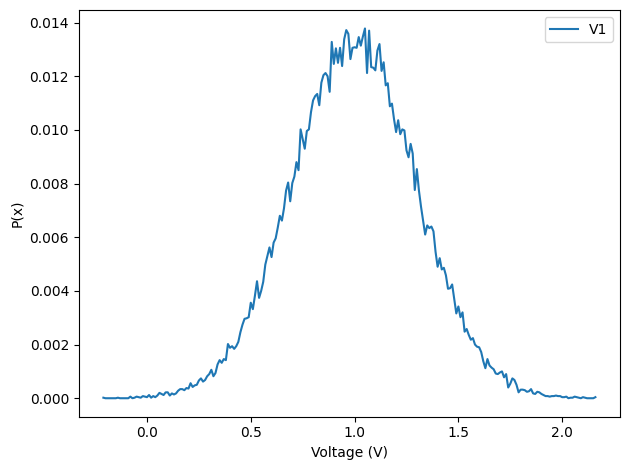

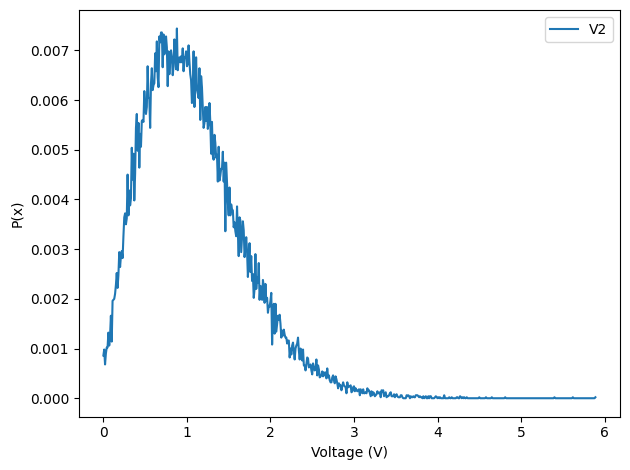

In [397]:
data = np.loadtxt('Voltages.txt', skiprows=1, delimiter=' ')
t = data[0, :]
V = data[1, :]
res = data[2, :]

bin_centers1, px1 = PMF(V, 0.01)  # 10mV resolution
bin_centers2, px2 = PMF(res, 0.01)

print(np.sum(px1))  # should be 1
print(np.sum(px2))  # should be 1

plot_plot(
    (bin_centers1, px1, 'V1'),
    xlabel='Voltage (V)',
    ylabel='P(x)'
)
plot_plot(
    (bin_centers2, px2, 'V2'),
    xlabel='Voltage (V)',
    ylabel='P(x)'
)


### c)

Sie haben in der Vorlesung die Begriffe Mode, Median und Mittelwert kennengelernt. Schreiben Sie eine Funktion, die ein Set an Daten und deren Auflösung als Argument nimmt und die Mode und den Median der Daten zurückgibt. Sie können zur Hilfe auch geeignete Numpy Funktionen verwenden.

In [398]:
def mode_meridian(data, resolution):
    idk, probability = PMF(data, resolution)
    mode = idk[np.argmax(probability)]
    median = np.median(data)
    return mode, median

print(mode_meridian(V, 0.001))
print(mode_meridian(res, 0.001))

(np.float64(1.0500000000000012), np.float64(1.0))
(np.float64(0.88), np.float64(1.0))


### d)

Plotten Sie nun die Mode, den Median und den Mittelwert der Datensätze in die PMF. Was für Unterschiede werden deutlich?

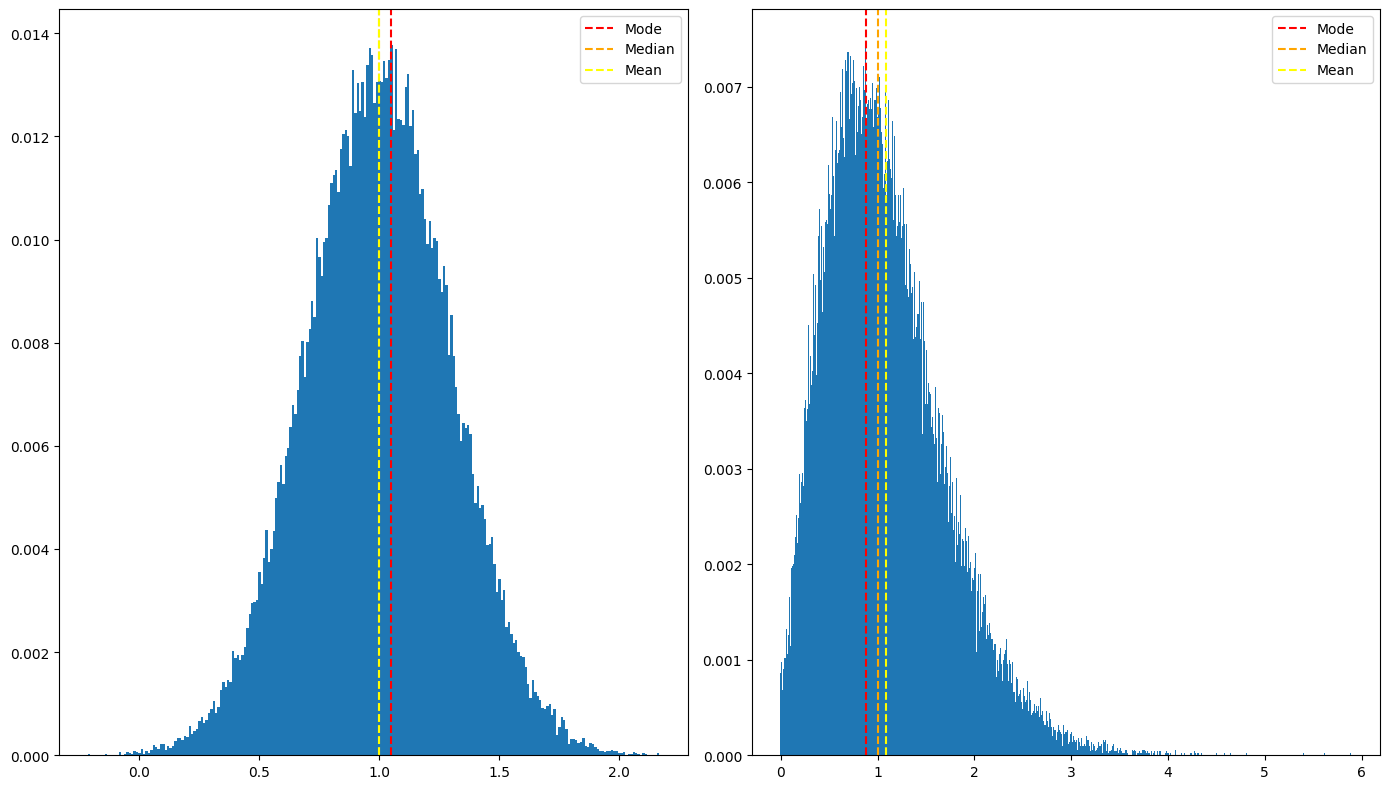

In [399]:
resolution = 0.01
bar_width = 1

mode, median = mode_meridian(V, resolution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
x1, px1 = PMF(V, resolution)
x2, px2 = PMF(res, resolution)
ax1.bar(x1, px1, resolution * bar_width)

mode, median = mode_meridian(V, resolution)
ax1.axvline(x=mode, color='red', linestyle='--', label='Mode')
ax1.axvline(x=median, color='orange', linestyle='--', label='Median')
ax1.axvline(x=np.mean(V), color='yellow', linestyle='--', label='Mean')

ax2.bar(x2, px2, resolution * bar_width)

mode, median = mode_meridian(res, resolution)
ax2.axvline(x=mode, color='red', linestyle='--', label='Mode')
ax2.axvline(x=median, color='orange', linestyle='--', label='Median')
ax2.axvline(x=np.mean(res), color='yellow', linestyle='--', label='Mean')

ax1.legend()
ax2.legend()
plt.tight_layout()



### e)

Eine wichtige Kenngrösse einer Verteilung ist deren Breite, und eine häufig verwendete Definition dafür ist die Breite auf halber Höhe (full width at half maximum oder kurz FWHM). Schreiben Sie eine Funktion, die die FWHM für eine Verteilung berechnet, die ein einzelnes Maximum aufweist. Für Datensätze mit starkem Rauschen kann das Finden des halben Wertes komplizierter werden. Sie haben bereits Methoden gesehen, wie man Daten glätten kann, nehmen Sie also für diese Aufgabe an, dass das Rauschen der Daten kleiner ist als deren Auflösung.

In [400]:
def FWHM(data, resolution):
    bin_centers, px = PMF(data, resolution)
    half_max = np.max(px) / 2
    indices = np.where(px >= half_max)[0]
    return abs(bin_centers[indices[-1]] - bin_centers[indices[0]])

print(FWHM(V, resolution))
print(FWHM(res, resolution))



0.6600000000000006
1.34


### f)

Berechnen Sie die FWHM der PMF der Daten aus den beiden Datensätzen. Für normalverteilte Daten kann die FWHM auch analytisch berechnet werden. Dabei gilt, dass $\mathrm{FWHM} = 2\sigma\sqrt{2\log{2}}$, wobei $\sigma$ die Wurzel der Varianz ist. Vergleichen Sie das Resultat Ihrer Funktion mit der FWHM, die Sie aus der Varianz berechnen. Können Sie die Abweichungen erklären? (Der symmetrische Datensatz ist Normalverteilt.)

In [401]:
def FWHM_n(data):
    return 2 * np.std(data, ddof=1) * np.sqrt(2 * np.log(2))

print(FWHM(V, resolution))          # given the data, more accurate
print(FWHM_n(V))                    # mathematically more correct

print(FWHM(res, resolution))
print(FWHM_n(res))                  # no bueno. the data is not distributed normally

0.6600000000000006
0.7059836868230026
1.34
1.4401942516127102


#  Aufgabe 2 Momente

Momente sind charakteristische Grössen für Zufallsvariablen und sind verknüpft mit Erwartungswert, Varianz, Schiefe etc. In der Vorlesung haben Sie die Formel für das n-te Moment von diskrete Zufallsvariablen gesehen:

$$m_n = \sum_{i=0}^{N}x^n_ip_i,$$

wobei der Wert $x_i$ mit Wahrscheinlichkeit $p_i$ im Datensatz vorkommt. Da $p_i = \frac{n_i}{M}$, wobei $M$ die Länge des Datenarrays und $n_i$ die Anzahl Datenpunkte $X_j$ mit Wert $x_i$ im Datenarray ist, kann man das n-te Moment auch via:

$$ m_n =\frac{1}{M}\sum_{j=0}^{M}X_j^n $$
berechnen. Dies hat den Vorteil, dass man nicht auf ein Binning angewiesen ist.

### a)

Schreiben Sie eine Funktion, die das n-te Moment aus einem Datensatz berechnet.

In [402]:
def moment_simple(data, n):
    return np.mean(data**n)

def moment_complex(data, n, resolution=0.001):
    bin_centers, px = PMF(data, resolution)
    return np.sum(bin_centers**n * px)

for i in range(0, 4):
    print(f'simple: {moment_simple(V, i+1)}, complex: {moment_complex(V, i+1)}')


simple: 0.9975183999999999, complex: 0.9975184000000011
simple: 1.0849233999999999, complex: 1.0849234000000023
simple: 1.2616501156000002, complex: 1.261650115600004
simple: 1.5514037962936003, complex: 1.5514037962936065


### b)

Die ersten beiden Momente hängen mit dem Mittelwert und der Varianz zusammen. Berechnen Sie für die beiden Datensätze Mittelwert und Varianz einmal über die Momente und einmal mit Numpy und vergleichen Sie die Werte.

In [403]:
for data, name in [(V, 'V'), (res, 'res')]:
    m1 = moment_simple(data, 1)
    m2 = moment_simple(data, 2)
    var = m2 - m1**2

    print(f'{name}: mean={m1:.4f}, np.mean={np.mean(data):.4f}')
    print(f'{name}: var={var:.4f}, np.var={np.var(data):.4f}')


V: mean=0.9975, np.mean=0.9975
V: var=0.0899, np.var=0.0899
res: mean=1.0839, np.mean=1.0839
res: var=0.3740, np.var=0.3740


### c)

Die höheren Momente geben zusätzliche Informationen über die Symmetrie und die Breite der Verteilung. Berechnen und vergleichen Sie die ersten drei zentralen Momente für die beiden Datensätze.

In [404]:
def central_moment(data, n):
    return np.mean((data - np.mean(data))**n)


for i in range(0, 3):
    print(f'Symmetric: {central_moment(V, i+1)}, Asymmetric: {central_moment(res, i+1)}')


Symmetric: 1.0672351891116705e-16, Asymmetric: -7.958078640513122e-17
Symmetric: 0.08988044166144, Asymmetric: 0.37403996895600006
Symmetric: 0.00010427279461408649, Asymmetric: 0.20227324995777576
